In [19]:
!pip install torch torchvision segmentation-models-pytorch albumentations opencv-python matplotlib

In [20]:
!pip install -q kaggle

import kagglehub

kagglehub.login()

In [31]:
import os
import cv2
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import kagglehub

# Konfigurasi Pelatihan
CONFIG = {
    "IMAGE_WIDTH": 512,
    "IMAGE_HEIGHT": 384,
    "BATCH_SIZE": 8,
    "EPOCHS": 20,       # Mulai dari 20 epoch dulu untuk melihat tren belajarnya
    "LR": 1e-4,
    "NUM_CLASSES": 1,    # Segmentasi Biner (Banjir vs Background)
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu"
}
print(f"Menggunakan device: {CONFIG['DEVICE']}")

Menggunakan device: cuda


In [32]:
# 1. Unduh dataset FAD menggunakan kagglehub
path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")
print(f"Dataset tersimpan di: {path}")

# 2. Setup path
csv_path = os.path.join(path, "metadata.csv")
image_dir = os.path.join(path, "Image")
mask_dir = os.path.join(path, "Mask")

# 3. Class Dataset
class FADDataset(Dataset):
    def __init__(self, csv_file, img_dir, mask_dir, transform=None):
        from PIL import Image

        self.data_info = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.root_dir = os.path.dirname(img_dir)
        self.transform = transform
        self.Image = Image

        self.samples = []
        missing_count = 0
        unreadable_count = 0

        # Validasi path dan keterbacaan file sekali di awal agar training stabil
        for idx in range(len(self.data_info)):
            img_name = self._clean_name(self.data_info.iloc[idx, 0])
            mask_name = self._clean_name(self.data_info.iloc[idx, 1])

            img_path = self._resolve_existing_path(self.img_dir, img_name)
            mask_path = self._resolve_existing_path(self.mask_dir, mask_name)

            if not (os.path.isfile(img_path) and os.path.isfile(mask_path)):
                missing_count += 1
                continue

            # Di runtime Colab + Codespaces, beberapa JPG gagal dibaca cv2.
            # Simpan hanya sample yang bisa dibaca oleh cv2/PIL fallback.
            image = self._read_image_rgb(img_path)
            mask = self._read_mask_gray(mask_path)
            if image is None or mask is None:
                unreadable_count += 1
                continue

            self.samples.append((img_path, mask_path))

        if missing_count > 0:
            print(f"Melewati {missing_count} sampel karena file image/mask tidak ditemukan.")
        if unreadable_count > 0:
            print(f"Melewati {unreadable_count} sampel karena file tidak bisa dibaca decoder.")

        if len(self.samples) == 0:
            raise RuntimeError("Tidak ada pasangan image-mask valid. Cek metadata.csv dan folder dataset.")

    @staticmethod
    def _clean_name(value):
        return str(value).strip().replace("\\", "/")

    def _resolve_existing_path(self, base_dir, file_name):
        if os.path.isabs(file_name) and os.path.exists(file_name):
            return file_name

        candidates = [
            os.path.join(base_dir, file_name),
            os.path.join(self.root_dir, file_name),
            os.path.join(base_dir, os.path.basename(file_name)),
        ]

        for candidate in candidates:
            if os.path.exists(candidate):
                return candidate

        # Kembalikan kandidat pertama agar pesan error tetap informatif jika file tidak ada
        return candidates[0]

    def _read_image_rgb(self, img_path):
        image = cv2.imread(img_path)
        if image is not None:
            return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        try:
            with self.Image.open(img_path) as img:
                return np.array(img.convert("RGB"))
        except Exception:
            return None

    def _read_mask_gray(self, mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            return mask

        try:
            with self.Image.open(mask_path) as m:
                return np.array(m.convert("L"))
        except Exception:
            return None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        image = self._read_image_rgb(img_path)
        mask = self._read_mask_gray(mask_path)

        if image is None:
            raise FileNotFoundError(f"Gagal membaca image pada idx={idx}: {img_path}")
        if mask is None:
            raise FileNotFoundError(f"Gagal membaca mask pada idx={idx}: {mask_path}")

        # Paksa dimensi mask (Lebar, Tinggi) agar sama persis dengan image
        mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Normalisasi Mask biner (0 dan 1)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0)  # Format Pytorch: [C, H, W]
        return image, mask

# 4. Augmentasi & Dataloader
train_transform = A.Compose([
    A.Resize(CONFIG["IMAGE_HEIGHT"], CONFIG["IMAGE_WIDTH"]),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Memuat dataset (idealnya ini dibagi jadi train & validasi, tapi kita muat semua untuk contoh)
train_dataset = FADDataset(csv_path, image_dir, mask_dir, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)

print(f"Total gambar siap di-train: {len(train_dataset)}")

Using Colab cache for faster access to the 'flood-area-segmentation' dataset.
Dataset tersimpan di: /kaggle/input/flood-area-segmentation
Total gambar siap di-train: 290


In [28]:
# Smoke test dataloader sebelum training penuh
images_batch, masks_batch = next(iter(train_loader))
print("Batch image shape:", images_batch.shape)
print("Batch mask shape:", masks_batch.shape)

Batch image shape: torch.Size([8, 3, 384, 512])
Batch mask shape: torch.Size([8, 1, 384, 512])


In [24]:
# Inisialisasi U-Net dengan backbone tangguh
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["NUM_CLASSES"],
)
model = model.to(CONFIG["DEVICE"])

# Loss dan Optimizer
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["LR"])

# Fungsi pembantu untuk menghitung akurasi IoU
def calculate_iou(pred, target):
    pred = (pred.sigmoid() > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    if union == 0:
        return 1.0 # Menghindari pembagian dengan nol
    return (intersection / union).item()

In [30]:
print("Memulai Pelatihan...")

for epoch in range(CONFIG["EPOCHS"]):
    model.train()
    running_loss = 0.0
    running_iou = 0.0

    for images, masks in train_loader:
        images = images.to(CONFIG["DEVICE"])
        masks = masks.to(CONFIG["DEVICE"])

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_iou += calculate_iou(outputs, masks)

    epoch_loss = running_loss / len(train_loader)
    epoch_iou = running_iou / len(train_loader)

    print(f"Epoch [{epoch+1}/{CONFIG['EPOCHS']}] | Loss: {epoch_loss:.4f} | IoU Banjir: {epoch_iou:.4f}")

print("Pelatihan Selesai!")

Memulai Pelatihan...
Epoch [1/20] | Loss: 0.2332 | IoU Banjir: 0.7298
Epoch [2/20] | Loss: 0.2019 | IoU Banjir: 0.7560
Epoch [3/20] | Loss: 0.1748 | IoU Banjir: 0.7835
Epoch [4/20] | Loss: 0.1643 | IoU Banjir: 0.7940
Epoch [5/20] | Loss: 0.1435 | IoU Banjir: 0.8171
Epoch [6/20] | Loss: 0.1411 | IoU Banjir: 0.8159
Epoch [7/20] | Loss: 0.1291 | IoU Banjir: 0.8270
Epoch [8/20] | Loss: 0.1238 | IoU Banjir: 0.8329
Epoch [9/20] | Loss: 0.1217 | IoU Banjir: 0.8339
Epoch [10/20] | Loss: 0.1111 | IoU Banjir: 0.8442
Epoch [11/20] | Loss: 0.1054 | IoU Banjir: 0.8504
Epoch [12/20] | Loss: 0.0987 | IoU Banjir: 0.8543
Epoch [13/20] | Loss: 0.0925 | IoU Banjir: 0.8624
Epoch [14/20] | Loss: 0.0883 | IoU Banjir: 0.8688
Epoch [15/20] | Loss: 0.0867 | IoU Banjir: 0.8706
Epoch [16/20] | Loss: 0.0844 | IoU Banjir: 0.8731
Epoch [17/20] | Loss: 0.0843 | IoU Banjir: 0.8713
Epoch [18/20] | Loss: 0.0804 | IoU Banjir: 0.8755
Epoch [19/20] | Loss: 0.0747 | IoU Banjir: 0.8827
Epoch [20/20] | Loss: 0.0771 | IoU Ban

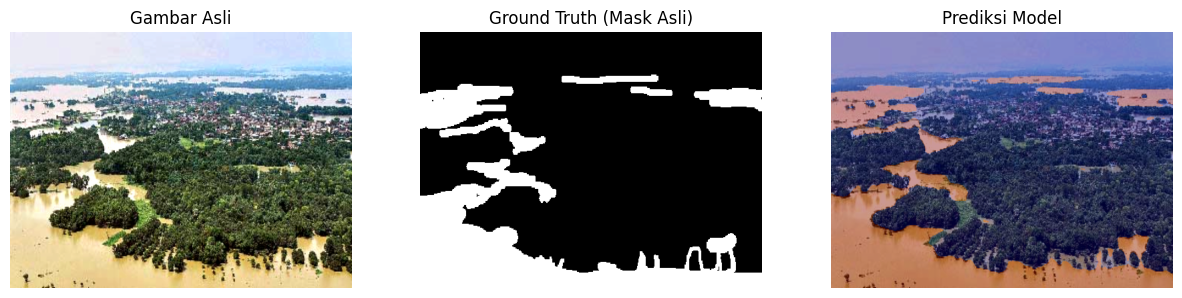

In [33]:
# Ambil satu batch data untuk dites
model.eval()
images, masks = next(iter(train_loader))
images = images.to(CONFIG["DEVICE"])

with torch.no_grad():
    preds = model(images)
    preds = (preds.sigmoid() > 0.5).float().cpu() # Ubah probabilitas jadi biner 0/1

# Visualisasikan gambar pertama dari batch
img_show = images[0].cpu().numpy().transpose(1, 2, 0)
# Denormalisasi gambar agar warnanya kembali normal saat di-plot
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_show = std * img_show + mean
img_show = np.clip(img_show, 0, 1)

mask_show = masks[0].cpu().numpy().squeeze()
pred_show = preds[0].numpy().squeeze()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_show)
ax[0].set_title("Gambar Asli")
ax[0].axis("off")

ax[1].imshow(mask_show, cmap="gray")
ax[1].set_title("Ground Truth (Mask Asli)")
ax[1].axis("off")

# Prediksi model (warna biru untuk area banjir)
ax[2].imshow(img_show)
ax[2].imshow(pred_show, cmap="jet", alpha=0.4)
ax[2].set_title("Prediksi Model")
ax[2].axis("off")

plt.show()

In [34]:
model.eval()

# Kita simpan total perhitungannya, bukan rata-rata per gambar (Global Metrics)
total_intersection = 0
total_union = 0
total_tp = 0
total_fp = 0
total_fn = 0

print("Evaluating model on the dataset...")

with torch.no_grad():
    for images, masks in train_loader:  # Ingat: idealnya ini pakai test_loader
        images = images.to(CONFIG['DEVICE'])
        masks = masks.to(CONFIG['DEVICE'])

        outputs = model(images)
        preds = (outputs.sigmoid() > 0.5).float()

        # Flatten tensor langsung di GPU
        preds_flat = preds.view(-1)
        masks_flat = masks.view(-1)

        # 1. Hitung komponen IoU
        intersection = (preds_flat * masks_flat).sum().item()
        union = preds_flat.sum() + masks_flat.sum() - intersection
        total_intersection += intersection
        total_union += union.item()

        # 2. Hitung komponen Precision & Recall (TP, FP, FN)
        total_tp += intersection  # True Positive sama dengan Intersection
        total_fp += (preds_flat * (1 - masks_flat)).sum().item()
        total_fn += ((1 - preds_flat) * masks_flat).sum().item()

# Hitung Metrik Akhir (ditambah epsilon 1e-8 untuk menghindari pembagian nol)
mean_iou = total_intersection / (total_union + 1e-8)
mean_precision = total_tp / (total_tp + total_fp + 1e-8)
mean_recall = total_tp / (total_tp + total_fn + 1e-8)
f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall + 1e-8)

print(f"--- Evaluation Results ---")
print(f"Mean IoU: {mean_iou:.4f}")
print(f"Mean Precision: {mean_precision:.4f}")
print(f"Mean Recall: {mean_recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

Evaluating model on the dataset...
--- Evaluation Results ---
Mean IoU: 0.8937
Mean Precision: 0.9361
Mean Recall: 0.9518
F1-Score: 0.9439
